Trend Analysis

By: Josh Navarro

Goal: Learn how to trend analysis in Jupyter Notebook, using the python pandas

Data: Created by ChatGPT

In [28]:
# Imports that I will be using 
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# The data we are going to use

df = pd.DataFrame({
    "month": [
        "2024-01", "2024-02", "2024-03", "2024-04",
        "2024-05", "2024-06", "2024-07", "2024-08",
        "2024-09", "2024-10", "2024-11", "2024-12"
    ],

    "website_visits": [
        1200, 1350, 1500, 1600,
        1750, 1900, 2100, 2300,
        2500, 2700, 3100, 3500
    ],

    "new_customers": [
        80, 92, 105, 110,
        125, 140, 155, 170,
        190, 210, 240, 280
    ],

    "orders": [
        150, 165, 180, 195,
        210, 230, 250, 275,
        300, 330, 370, 420
    ],

    "revenue": [
        4500, 5200, 6100, 6700,
        7300, 8100, 9000, 9800,
        11000, 12300, 14000, 16500
    ],

    "ad_spend": [
        900, 950, 1000, 1100,
        1150, 1200, 1300, 1400,
        1500, 1600, 1800, 2100
    ],

    "customer_satisfaction": [
        7.8, 7.9, 8.0, 8.1,
        8.2, 8.1, 8.3, 8.4,
        8.5, 8.6, 8.7, 8.8
    ]
})

df

,month,website_visits,new_customers,orders,revenue,ad_spend,customer_satisfaction
0,2024-01,1200,80,150,4500,900,7.8
1,2024-02,1350,92,165,5200,950,7.9
2,2024-03,1500,105,180,6100,1000,8.0
3,2024-04,1600,110,195,6700,1100,8.1
4,2024-05,1750,125,210,7300,1150,8.2
5,2024-06,1900,140,230,8100,1200,8.1
6,2024-07,2100,155,250,9000,1300,8.3
7,2024-08,2300,170,275,9800,1400,8.4
8,2024-09,2500,190,300,11000,1500,8.5
9,2024-10,2700,210,330,12300,1600,8.6


Trend Analysis

This refers to looking at the data over time to see what the values are saying relative to time

In [30]:
# Copy the dataframe
trend_df = df.copy()

1 Convert the Date Column

Converting the Date Column allows you to track the time based on the time. To do this you need to use the function of pd.to_datetieme()

In [31]:
# Convert the month column into a date time
trend_df['month'] = pd.to_datetime(trend_df['month'])
trend_df.dtypes

month                    datetime64[ns]
website_visits                    int64
new_customers                     int64
orders                            int64
revenue                           int64
ad_spend                          int64
customer_satisfaction           float64
dtype: object

2 Sort by Date

Sorting by the dates puts the data into ealiest and later which allows to follow the data through time. This is done by using the .sort_values()

In [32]:
# Sort the data frame by the date
trend_df = trend_df.sort_values(by = 'month')
trend_df.head() 

,month,website_visits,new_customers,orders,revenue,ad_spend,customer_satisfaction
0,2024-01-01,1200,80,150,4500,900,7.8
1,2024-02-01,1350,92,165,5200,950,7.9
2,2024-03-01,1500,105,180,6100,1000,8.0
3,2024-04-01,1600,110,195,6700,1100,8.1
4,2024-05-01,1750,125,210,7300,1150,8.2


3 Line Chart Trend

The line chart trend allows you to see how somethign is able to change over time. Will usually be a numeric values. This is done by using the matplotlib.

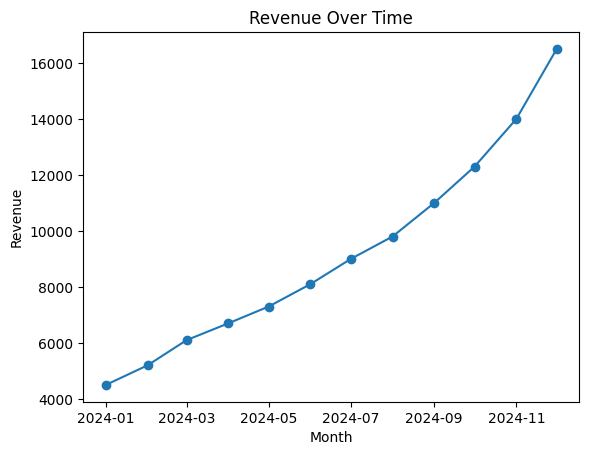

In [33]:
# Create a line chart for the revenue

plt.figure()
plt.plot(trend_df['month'], trend_df['revenue'], marker = "o")
plt.title("Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

4 Month over Month Difference

The month over month difference refers to how much a value has changed compared to the previous month. Which this is done by using the .diff() function.

In [34]:
# Find the change in Revenue
trend_df["revenue_change"] = trend_df["revenue"].diff()
# Check the dataframe
trend_df[["month", "revenue", "revenue_change"]]

,month,revenue,revenue_change
0,2024-01-01,4500,NaN
1,2024-02-01,5200,700.0
2,2024-03-01,6100,900.0
3,2024-04-01,6700,600.0
4,2024-05-01,7300,600.0
5,2024-06-01,8100,800.0
6,2024-07-01,9000,900.0
7,2024-08-01,9800,800.0
8,2024-09-01,11000,1200.0
9,2024-10-01,12300,1300.0


5 Month over Month Percent Change

Using the month over month you can find the percent changes from a month to another month. This is done by using the .percent_change() function

In [35]:
# Find the percent change for the revenue
trend_df["revenue_pct_change"] = trend_df["revenue"].pct_change() * 100
# Check the dataframe
trend_df[["month", "revenue", "revenue_pct_change"]]

,month,revenue,revenue_pct_change
0,2024-01-01,4500,NaN
1,2024-02-01,5200,15.555556
2,2024-03-01,6100,17.307692
3,2024-04-01,6700,9.836066
4,2024-05-01,7300,8.955224
5,2024-06-01,8100,10.958904
6,2024-07-01,9000,11.111111
7,2024-08-01,9800,8.888889
8,2024-09-01,11000,12.244898
9,2024-10-01,12300,11.818182


6 Rolling Average

The rolling average will basically smooth out the trend so that it is easier to see the overall direction. This is done by using the function .rolling() and the .mean()

In [36]:
# Find the revenue avg with a 3 month window
trend_df["revenue_3_month_avg"] = trend_df["revenue"].rolling(window=3).mean() # Window = 3 is the 3 month window
# Check the data frame
trend_df[["month", "revenue", "revenue_3_month_avg"]]

,month,revenue,revenue_3_month_avg
0,2024-01-01,4500,NaN
1,2024-02-01,5200,NaN
2,2024-03-01,6100,5266.666667
3,2024-04-01,6700,6000.000000
4,2024-05-01,7300,6700.000000
5,2024-06-01,8100,7366.666667
6,2024-07-01,9000,8133.333333
7,2024-08-01,9800,8966.666667
8,2024-09-01,11000,9933.333333
9,2024-10-01,12300,11033.333333


7 Plot Revenue with Rolling Average

You are able to plot the revenue with rolling average to visualize the how smooth it makes the direction seem. This is done by using the matplotlib.

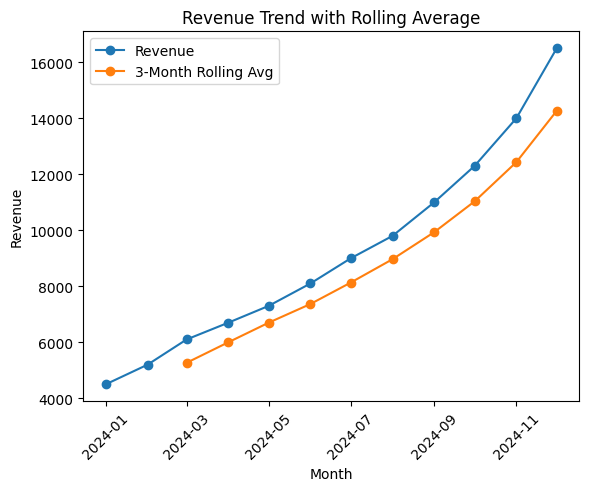

In [37]:
# Create a line with the rolling average and regular
plt.figure()
plt.plot(trend_df["month"], trend_df["revenue"], marker="o", label="Revenue")
plt.plot(trend_df["month"], trend_df["revenue_3_month_avg"], marker="o", label="3-Month Rolling Avg")
plt.title("Revenue Trend with Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.show()

8 Cumulative Sum

The cumulative sum shows the runnin over total time. This is done by using the  function .cumsum()

In [38]:
# Find the cumulative sum using the revenue
trend_df["cumulative_revenue"] = trend_df["revenue"].cumsum()
# Check the dataframe
trend_df[["month", "revenue", "cumulative_revenue"]]

,month,revenue,cumulative_revenue
0,2024-01-01,4500,4500
1,2024-02-01,5200,9700
2,2024-03-01,6100,15800
3,2024-04-01,6700,22500
4,2024-05-01,7300,29800
5,2024-06-01,8100,37900
6,2024-07-01,9000,46900
7,2024-08-01,9800,56700
8,2024-09-01,11000,67700
9,2024-10-01,12300,80000


9 Compare Two Trends

Comparing two columns allows you to see how each of them are performing compared to each other. A way to do this is by plotting both of the columns in a line chart.

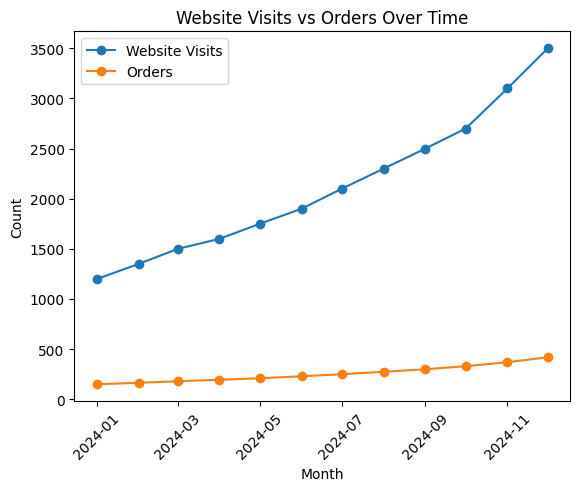

In [39]:
# Plot the line chart and compare the order and website visits
plt.figure()
plt.plot(trend_df["month"], trend_df["website_visits"], marker="o", label="Website Visits")
plt.plot(trend_df["month"], trend_df["orders"], marker="o", label="Orders")
plt.title("Website Visits vs Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.show()

10 Conversion Rate Trend

The conversion rate trend tracks the ratio of two columns depending on what you choose. This is able to create  trend that is positive or negative. This is also done by just dividing the columns

In [40]:
# Find conversion rate for the orders and the website visits
trend_df["conversion_rate"] = trend_df["orders"] / trend_df["website_visits"]
# Check the data frame
trend_df[["month", "website_visits", "orders", "conversion_rate"]]

,month,website_visits,orders,conversion_rate
0,2024-01-01,1200,150,0.125000
1,2024-02-01,1350,165,0.122222
2,2024-03-01,1500,180,0.120000
3,2024-04-01,1600,195,0.121875
4,2024-05-01,1750,210,0.120000
5,2024-06-01,1900,230,0.121053
6,2024-07-01,2100,250,0.119048
7,2024-08-01,2300,275,0.119565
8,2024-09-01,2500,300,0.120000
9,2024-10-01,2700,330,0.122222


11 ROI Trend

Using the same equation you can also find the ROI trend or the return on invesment. This is done by using  a revenue column and dividing it by a spending/investment column. 

In [41]:
# Find the return on ad spent
trend_df["return_on_ad_spend"] = trend_df["revenue"] / trend_df["ad_spend"]
# Check the dataframe
trend_df[["month", "revenue", "ad_spend", "return_on_ad_spend"]]

,month,revenue,ad_spend,return_on_ad_spend
0,2024-01-01,4500,900,5.000000
1,2024-02-01,5200,950,5.473684
2,2024-03-01,6100,1000,6.100000
3,2024-04-01,6700,1100,6.090909
4,2024-05-01,7300,1150,6.347826
5,2024-06-01,8100,1200,6.750000
6,2024-07-01,9000,1300,6.923077
7,2024-08-01,9800,1400,7.000000
8,2024-09-01,11000,1500,7.333333
9,2024-10-01,12300,1600,7.687500


12 Find Highest and Lowest Months

You can find the lowest and highest months by using the loc[] which finds that, and then the functions of idxmin() and the idxmax()

In [42]:
# Find the highest month
trend_df.loc[trend_df["revenue"].idxmax()]

month                    2024-12-01 00:00:00
website_visits                          3500
new_customers                            280
orders                                   420
revenue                                16500
ad_spend                                2100
customer_satisfaction                    8.8
revenue_change                        2500.0
revenue_pct_change                 17.857143
revenue_3_month_avg             14266.666667
cumulative_revenue                    110500
conversion_rate                         0.12
return_on_ad_spend                  7.857143
Name: 11, dtype: object

In [43]:
# Find the lowest month 
trend_df.loc[trend_df["revenue"].idxmin()]

month                    2024-01-01 00:00:00
website_visits                          1200
new_customers                             80
orders                                   150
revenue                                 4500
ad_spend                                 900
customer_satisfaction                    7.8
revenue_change                           NaN
revenue_pct_change                       NaN
revenue_3_month_avg                      NaN
cumulative_revenue                      4500
conversion_rate                        0.125
return_on_ad_spend                       5.0
Name: 0, dtype: object

13 Trend Summary with .agg()

Using the .agg() function you can do multiple aggregations on different columns to give a certain idea of what is going on. This is done by passign the list of aggregation.

In [44]:
# use many aggregations on different columns
trend_df[["website_visits", "new_customers", "orders", "revenue", "ad_spend"]].agg(
    ["min", "max", "mean", "median", "std"]
)

,website_visits,new_customers,orders,revenue,ad_spend
min,1200.000000,80.000000,150.00000,4500.000000,900.000000
max,3500.000000,280.000000,420.00000,16500.000000,2100.000000
mean,2125.000000,158.083333,256.25000,9208.333333,1333.333333
median,2000.000000,147.500000,240.00000,8550.000000,1250.000000
std,717.159802,62.125179,85.01671,3672.368157,364.525428


14 Simple Trend Direction Check

Comparing the first and last values you are able to describe the trend. This is doen by using the .iloc() and passing the values -1 for the last, and 0 for the first.

In [45]:
# Find the first and last revenue
first_revenue = trend_df["revenue"].iloc[0]
last_revenue = trend_df["revenue"].iloc[-1]
# Check if they increased over time or did not increse
if last_revenue > first_revenue:
    print("Revenue increased over time")
elif last_revenue < first_revenue:
    print("Revenue decreased over time")
else:
    print("Revenue stayed the same")

Revenue increased over time
